# Notebook 3: Risk Modifiers and Validation

This notebook adds **physical risk disqualifiers** to the composite siting suitability score
from Notebook 2 and **validates** the risk-adjusted index against documented cases of
canceled or blocked data center projects.

**New layers:**

1. **Seismic Hazard** — Peak Ground Acceleration (PGA) at 2% probability of exceedance in
   50 years, from the [USGS 2018 National Seismic Hazard Model](https://www.usgs.gov/programs/earthquake-hazards/2018-long-term-national-seismic-hazard-map).
   Western WA faces both Cascadia Subduction Zone megathrust risk and shallow crustal fault
   hazard (Seattle Fault, South Whidbey Island Fault). Eastern WA has substantially lower
   PGA. Higher seismic hazard = higher construction, insurance, and business continuity cost.

2. **Flood Risk** — FEMA National Flood Hazard Layer (NFHL), Special Flood Hazard Area
   designation (100-year floodplain). From the
   [FEMA NFHL REST service](https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer).
   Data centers sited in SFHA face mandatory flood insurance, elevation requirements, and
   operational risk during high-flow events. Several canceled projects nationally cited
   environmental permitting delays tied to floodplain proximity.

**Revised composite:** 60% NB2 opportunity score + 20% seismic safety + 20% flood safety.

**Validation:** Scored locations of documented canceled or blocked data center projects
against the risk-adjusted index. The thesis: projects that collapsed under community or
regulatory opposition cluster at low scores on one or more indicator dimensions.


## Data Sources

| Layer | Source | License | Access |
|---|---|---|---|
| NB2 opportunity layers | Cached (see Notebook 2) | Various | Local |
| Seismic hazard (PGA) | [USGS 2018 NSHM design values API](https://earthquake.usgs.gov/ws/designmaps/) | Public domain | REST API, sampled + IDW |
| Flood hazard zones | [FEMA NFHL REST service](https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28) | Public domain | Tiled REST queries |
| Canceled projects | [Data Center Dynamics, 2025](https://www.datacenterdynamics.com); [Heatmap News, 2025](https://heatmap.news/politics/data-center-cancellations-2025); press releases | Various | Hard-coded from reporting |


In [1]:
import io
import time
import zipfile
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import requests
from shapely.geometry import box, Point

warnings.filterwarnings('ignore')

RAW = Path('data/raw')
PROCESSED = Path('data/processed')
CRS = 'EPSG:4326'
CRS_PROJ = 'EPSG:32610'

# ── rebuild analysis grid (cached layers from NB2) ──────────────────────────
wa      = gpd.read_file(RAW / 'wa_state.geojson')
dc_gdf  = gpd.read_file(RAW / 'datacenters.geojson')
tx_gdf  = gpd.read_file(RAW / 'transmission_wa.geojson')

def create_fishnet(extent_gdf, cell_size_deg=0.15):
    xmin, ymin, xmax, ymax = extent_gdf.total_bounds
    xs = np.arange(xmin, xmax + cell_size_deg, cell_size_deg)
    ys = np.arange(ymin, ymax + cell_size_deg, cell_size_deg)
    cells = [box(x, y, x + cell_size_deg, y + cell_size_deg)
             for x in xs[:-1] for y in ys[:-1]]
    grid = gpd.GeoDataFrame({'geometry': cells}, crs=CRS)
    wa_union = extent_gdf.geometry.unary_union
    grid = grid[grid.centroid.within(wa_union)].reset_index(drop=True)
    grid['cell_id'] = range(len(grid))
    return grid

def idw(src_lats, src_lons, src_vals, tgt_lats, tgt_lons, power=2):
    results = []
    for lat, lon in zip(tgt_lats, tgt_lons):
        dists = np.sqrt((src_lats - lat)**2 + (src_lons - lon)**2)
        dists = np.maximum(dists, 1e-10)
        w = 1.0 / dists**power
        results.append(float(np.sum(w * src_vals) / np.sum(w)))
    return results

grid = create_fishnet(wa)

# ── transmission score (NB2) ─────────────────────────────────────────────────
tx_proj       = tx_gdf.to_crs(CRS_PROJ)
tx_union      = tx_proj.geometry.unary_union
grid_proj     = grid.to_crs(CRS_PROJ)
centroids_proj = list(grid_proj.geometry.centroid)
grid['tx_dist_m'] = [tx_union.distance(pt) for pt in centroids_proj]
grid['tx_score']  = 1.0 - (grid['tx_dist_m'] / grid['tx_dist_m'].max())

# ── EJ score (NB2) ───────────────────────────────────────────────────────────
df     = pd.read_csv(RAW / 'acs_demog_wa.csv', dtype={'GEOID': str})
tracts = gpd.read_file(RAW / 'wa_tracts.geojson')
tracts['GEOID'] = tracts['GEOID'].astype(str).str.zfill(11)
df['GEOID']     = df['GEOID'].astype(str).str.zfill(11)
ej_gdf          = tracts[['GEOID', 'geometry']].merge(df[['GEOID', 'demog_index']], on='GEOID', how='left')
grid_pts        = gpd.GeoDataFrame({'cell_id': grid['cell_id']}, geometry=grid.geometry.centroid, crs=CRS)
joined          = gpd.sjoin(grid_pts, ej_gdf[['GEOID', 'demog_index', 'geometry']], how='left', predicate='within')
burden_by_cell  = joined.groupby('cell_id')['demog_index'].mean()
grid['demog_burden'] = grid['cell_id'].map(burden_by_cell)
q01, q99 = grid['demog_burden'].quantile([0.01, 0.99])
grid['ej_score'] = 1.0 - ((grid['demog_burden'] - q01) / (q99 - q01)).clip(0, 1)
grid['ej_score'] = grid['ej_score'].fillna(grid['ej_score'].median())

# ── water score (NB2) ────────────────────────────────────────────────────────
precip_df = pd.read_csv(RAW / 'wa_precip_coarse.csv')
centroids = grid.geometry.centroid
tgt_lats  = np.array([p.y for p in centroids])
tgt_lons  = np.array([p.x for p in centroids])
grid['ann_precip_mm'] = idw(
    precip_df['lat'].values, precip_df['lon'].values,
    precip_df['ann_precip_mm'].values, tgt_lats, tgt_lons
)
p05, p95 = grid['ann_precip_mm'].quantile([0.05, 0.95])
grid['water_score'] = ((grid['ann_precip_mm'] - p05) / (p95 - p05)).clip(0, 1)

# ── NB2 composite (baseline) ─────────────────────────────────────────────────
grid['composite'] = 0.40 * grid['tx_score'] + 0.35 * grid['water_score'] + 0.25 * grid['ej_score']

print(f'Grid rebuilt: {len(grid)} cells')
print(f'Composite range: {grid["composite"].min():.3f} - {grid["composite"].max():.3f}')


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


Grid rebuilt: 974 cells
Composite range: 0.246 - 0.996


## 1. Seismic Hazard

Peak Ground Acceleration (PGA) at 2% probability of exceedance in 50 years (~2475-year
return period), sampled from the
[USGS 2018 National Seismic Hazard Model design values API](https://earthquake.usgs.gov/ws/designmaps/asce7-22.json).
Sampled on a coarse grid over WA interior points, then IDW-interpolated to the analysis grid.

WA seismic context:
- **Cascadia Subduction Zone** (offshore) generates M8.0–9.3 megathrust events; amplification
  is highest in the Puget Lowland due to deep sedimentary basin effects.
- **Crustal faults** — Seattle Fault, South Whidbey Island Fault, Tacoma Fault — can generate
  M6.5–7.5 events directly beneath urban centers.
- **Eastern WA** is far from the subduction zone; PGA is roughly 4–10x lower than Puget Sound.

A data center with >$200M capital investment requires detailed site-specific seismic hazard
analysis. High PGA = higher structural cost, higher insurance cost, higher business continuity
risk. This score captures relative risk, not absolute engineering thresholds.

**Score convention:** 1.0 = lowest seismic hazard (best); 0.0 = highest PGA.

*Source:* [USGS 2018 NSHM](https://www.usgs.gov/programs/earthquake-hazards/2018-long-term-national-seismic-hazard-map);
[WA Seismic Safety Committee](https://mil.wa.gov/seismic-safety-committee)


In [2]:
seismic_path = RAW / 'wa_seismic_sample.csv'

if not seismic_path.exists():
    print('Sampling USGS seismic hazard values...')
    wa_bounds = wa.total_bounds
    wa_union  = wa.geometry.unary_union

    sample_lats = np.linspace(wa_bounds[1] + 0.4, wa_bounds[3] - 0.2, 6)
    sample_lons = np.linspace(wa_bounds[0] + 0.4, wa_bounds[2] - 0.2, 10)

    records = []
    api_url = 'https://earthquake.usgs.gov/ws/designmaps/asce7-22.json'
    for lat in sample_lats:
        for lon in sample_lons:
            if not wa_union.contains(Point(lon, lat)):
                continue
            try:
                params = {
                    'latitude':     round(lat, 2),
                    'longitude':    round(lon, 2),
                    'riskCategory': 'II',
                    'siteClass':    'C',
                    'title':        'datacenter-siting'
                }
                r = requests.get(api_url, params=params,
                                 headers={'User-Agent': 'datacenter-siting-research/1.0'},
                                 timeout=30)
                r.raise_for_status()
                data = r.json().get('response', {}).get('data', {})
                pgam = data.get('pgam')
                if pgam is not None:
                    records.append({'lat': lat, 'lon': lon, 'pgam': float(pgam)})
                    print(f'  ({lat:.2f},{lon:.2f}) PGAM={pgam:.3f}g')
                time.sleep(0.3)
            except Exception as e:
                print(f'  Skipped ({lat:.2f},{lon:.2f}): {e}')

    seismic_df = pd.DataFrame(records)
    seismic_df.to_csv(seismic_path, index=False)
    print(f'Saved {len(seismic_df)} seismic sample points.')
else:
    seismic_df = pd.read_csv(seismic_path)
    print(f'Loaded {len(seismic_df)} cached seismic points.')

print(f'PGAM range: {seismic_df["pgam"].min():.3f}g - {seismic_df["pgam"].max():.3f}g')


Loaded 50 cached seismic points.
PGAM range: 0.150g - 1.040g


In [3]:
grid['pgam'] = idw(
    seismic_df['lat'].values, seismic_df['lon'].values,
    seismic_df['pgam'].values, tgt_lats, tgt_lons
)

p05s, p95s = grid['pgam'].quantile([0.05, 0.95])
grid['seismic_score'] = 1.0 - ((grid['pgam'] - p05s) / (p95s - p05s)).clip(0, 1)

print(f'PGAM interpolated: {grid["pgam"].min():.3f}g - {grid["pgam"].max():.3f}g')
print(f'Seismic score range: {grid["seismic_score"].min():.3f} - {grid["seismic_score"].max():.3f}')
print(f'  Mean: {grid["seismic_score"].mean():.3f}, Std: {grid["seismic_score"].std():.3f}')


PGAM interpolated: 0.150g - 1.027g
Seismic score range: 0.000 - 1.000
  Mean: 0.685, Std: 0.315


## 2. Flood Risk (FEMA NFHL)

Special Flood Hazard Area (SFHA) designations from the
[FEMA National Flood Hazard Layer](https://www.fema.gov/flood-maps/national-flood-hazard-layer),
queried via the FEMA NFHL ArcGIS REST service in tiled bounding boxes covering Washington State.

SFHA = Zone A, AE, AH, AO, AR, A99, VE, V — the 100-year floodplain. Siting a data center
in SFHA triggers:
- Mandatory federal flood insurance
- FEMA elevation requirements (equipment above base flood elevation)
- Potential NEPA/SEPA delays for permitting
- Operational risk during Columbia/Spokane/Snoqualmie high-flow events

Several canceled projects nationally were slowed or blocked by floodplain permitting requirements.

The NFHL REST service returns up to 1000 features per tile; we query 12 tiles covering WA and
union the results. Some gaps may occur in areas without completed FIRM maps.

**Score convention:** 1.0 = no SFHA overlap (low flood risk); 0.0 = cell centroid in SFHA.

*Source:* [FEMA NFHL REST API](https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28)


In [4]:
flood_path = RAW / 'wa_sfha.geojson'

if not flood_path.exists():
    print('Querying FEMA NFHL flood zones in tiles...')
    nfhl_url = ('https://hazards.fema.gov/arcgis/rest/services/'
                'public/NFHL/MapServer/28/query')

    # 40-tile grid (8 lon x 5 lat) — smaller tiles avoid 500s from large geometry payloads
    wa_bounds = wa.total_bounds  # xmin, ymin, xmax, ymax
    lon_edges = np.linspace(wa_bounds[0], wa_bounds[2], 9)
    lat_edges = np.linspace(wa_bounds[1], wa_bounds[3], 6)

    all_features = []
    for i in range(len(lat_edges) - 1):
        for j in range(len(lon_edges) - 1):
            xmin = lon_edges[j];   xmax = lon_edges[j + 1]
            ymin = lat_edges[i];   ymax = lat_edges[i + 1]
            bbox = f'{xmin},{ymin},{xmax},{ymax}'
            try:
                params = {
                    'geometry':            bbox,
                    'geometryType':        'esriGeometryEnvelope',
                    'inSR':                '4326',
                    'spatialRel':          'esriSpatialRelIntersects',
                    'where':               "FLD_ZONE IN ('A','AE','AH','AO','AR','A99','VE','V')",
                    'outFields':           'FLD_ZONE',
                    'returnGeometry':      'true',
                    'outSR':               '4326',
                    'resultRecordCount':   '1000',
                    'f':                   'geojson'
                }
                r = requests.get(nfhl_url, params=params,
                                 headers={'User-Agent': 'datacenter-siting-research/1.0'},
                                 timeout=60)
                r.raise_for_status()
                feats = r.json().get('features', [])
                all_features.extend(feats)
                print(f'  Tile ({ymin:.1f}-{ymax:.1f}N, {xmin:.1f}-{xmax:.1f}W): {len(feats)} SFHA features')
                time.sleep(0.2)
            except Exception as e:
                print(f'  Tile ({ymin:.1f}-{ymax:.1f}N, {xmin:.1f}-{xmax:.1f}W): skipped ({e})')

    if all_features:
        sfha_gdf = gpd.GeoDataFrame.from_features(all_features, crs=CRS)
        sfha_gdf = sfha_gdf[sfha_gdf.geometry.is_valid].dissolve().reset_index(drop=True)
        sfha_gdf.to_file(flood_path, driver='GeoJSON')
        print(f'Saved {len(sfha_gdf)} SFHA polygon(s) after dissolve.')
    else:
        print('WARNING: No SFHA features returned. Flood score will default to 1.0.')
        sfha_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=CRS)
        sfha_gdf.to_file(flood_path, driver='GeoJSON')
else:
    sfha_gdf = gpd.read_file(flood_path)
    print(f'Loaded SFHA polygons from cache: {len(sfha_gdf)} feature(s)')


Loaded SFHA polygons from cache: 12640 feature(s)


In [5]:
if len(sfha_gdf) > 0 and sfha_gdf.geometry.notna().any():
    # Use sjoin — avoids unary_union topology issues with complex polygon sets
    sfha_valid = sfha_gdf[sfha_gdf.geometry.is_valid].reset_index(drop=True)
    hit = gpd.sjoin(grid_pts, sfha_valid[['geometry']], how='left', predicate='intersects')
    flooded_ids = set(hit.loc[hit['index_right'].notna(), 'cell_id'])
    grid['in_sfha']     = grid['cell_id'].isin(flooded_ids)
    grid['flood_score'] = (~grid['in_sfha']).astype(float)
else:
    print('No SFHA data available; setting flood_score=1.0 for all cells.')
    grid['in_sfha']     = False
    grid['flood_score'] = 1.0

n_sfha = grid['in_sfha'].sum()
print(f'Cells with centroid in SFHA: {n_sfha} / {len(grid)} ({100*n_sfha/len(grid):.1f}%)')
print(f'Flood score range: {grid["flood_score"].min():.1f} - {grid["flood_score"].max():.1f}')


Cells with centroid in SFHA: 24 / 974 (2.5%)
Flood score range: 0.0 - 1.0


## 3. Risk-Adjusted Composite Score

The original NB2 composite (40% transmission + 35% water + 25% community burden) measures
*siting opportunity*. Seismic and flood scores measure *physical risk*. Risk is a disqualifier,
not an enhancer — a perfect opportunity score in an active fault zone or floodplain is not a
good site.

**Revised weighting:**

| Layer | Weight | Rationale |
|---|---|---|
| NB2 opportunity composite | 60% | Core siting factors from Notebook 2 |
| Seismic safety (inverse PGA) | 20% | Capital and insurance cost multiplier |
| Flood safety (SFHA inverse) | 20% | Permitting risk + operational exposure |

The 60/20/20 split treats risk factors as meaningful but not dominant — a slightly elevated
seismic risk in a high-water, low-burden location can still be a better choice than the
water-constrained Quincy corridor. Operators adjust this weighting in practice based on
their insurance and resilience requirements.


In [6]:
grid['risk_adjusted'] = (
    0.60 * grid['composite'] +
    0.20 * grid['seismic_score'] +
    0.20 * grid['flood_score']
)

print(f'NB2 composite range:       {grid["composite"].min():.3f} - {grid["composite"].max():.3f}')
print(f'Seismic score range:       {grid["seismic_score"].min():.3f} - {grid["seismic_score"].max():.3f}')
print(f'Flood score range:         {grid["flood_score"].min():.3f} - {grid["flood_score"].max():.3f}')
print(f'Risk-adjusted range:       {grid["risk_adjusted"].min():.3f} - {grid["risk_adjusted"].max():.3f}')
print()

# Score existing data centers
dc_full = gpd.sjoin(
    dc_gdf[['name', 'operator', 'source', 'geometry']],
    grid[['composite', 'seismic_score', 'flood_score', 'risk_adjusted', 'pgam', 'in_sfha', 'geometry']],
    how='left', predicate='within'
)
cols = ['name', 'composite', 'seismic_score', 'flood_score', 'risk_adjusted', 'pgam', 'in_sfha']
cols = [c for c in cols if c in dc_full.columns]
print('Existing data center risk-adjusted scores:')
tbl = dc_full[cols].copy()
for c in ['composite', 'seismic_score', 'flood_score', 'risk_adjusted']:
    if c in tbl: tbl[c] = tbl[c].round(3)
if 'pgam' in tbl: tbl['pgam'] = tbl['pgam'].round(3)
print(tbl.to_string(index=False))


NB2 composite range:       0.246 - 0.996
Seismic score range:       0.000 - 1.000
Flood score range:         0.000 - 1.000
Risk-adjusted range:       0.393 - 0.923

Existing data center risk-adjusted scores:
                                name  composite  seismic_score  flood_score  risk_adjusted  pgam  in_sfha
             Microsoft Quincy Campus      0.599          0.885          1.0          0.737 0.242    False
                        Vantage WA13      0.599          0.885          1.0          0.737 0.242    False
                     CyrusOne Quincy      0.599          0.885          1.0          0.737 0.242    False
                    Sabey SDC Quincy      0.599          0.885          1.0          0.737 0.242    False
           H5 Data Centers Quincy II      0.599          0.885          1.0          0.737 0.242    False
                 Dell / Yahoo Quincy      0.599          0.885          1.0          0.737 0.242    False
               Microsoft EAT06/EAT09      0.656   

## 4. Maps


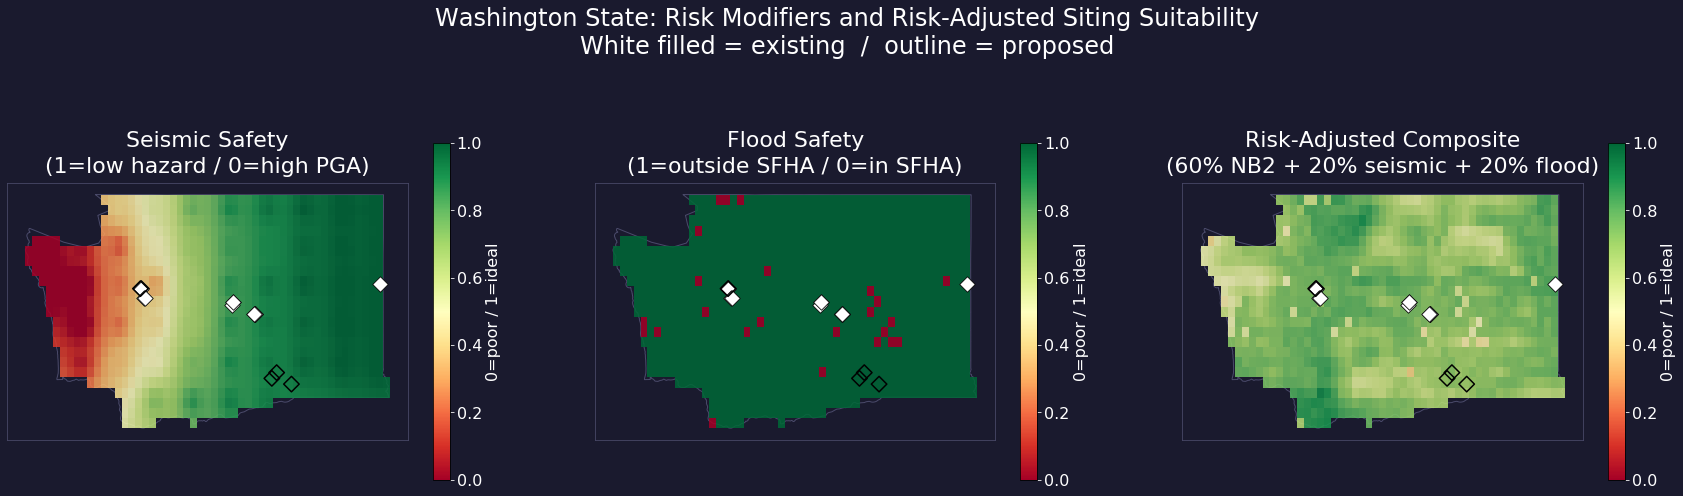

Saved to data/processed/risk_layers.png


In [7]:
DARK_BG = '#1a1a2e'
WHITE = 'white'

plt.rcParams.update({
    'text.color': WHITE,
    'axes.labelcolor': WHITE,
    'xtick.color': WHITE,
    'ytick.color': WHITE,
    'font.size': 18,
})

fig, axes = plt.subplots(1, 3, figsize=(24, 9), facecolor=DARK_BG)

risk_layers = [
    ('seismic_score', 'Seismic Safety',           '(1=low hazard / 0=high PGA)'),
    ('flood_score',   'Flood Safety',              '(1=outside SFHA / 0=in SFHA)'),
    ('risk_adjusted', 'Risk-Adjusted Composite',   '(60% NB2 + 20% seismic + 20% flood)'),
]

for ax, (col, title, subtitle) in zip(axes, risk_layers):
    ax.set_facecolor(DARK_BG)
    wa.boundary.plot(ax=ax, color='#4a4a6a', linewidth=1.0, zorder=1)
    n_before = len(fig.axes)
    grid.plot(column=col, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
              legend=True, legend_kwds={'shrink': 0.65, 'label': '0=poor / 1=ideal'},
              alpha=0.85, zorder=2)
    if len(fig.axes) > n_before:
        cb_ax = fig.axes[-1]
        cb_ax.tick_params(labelsize=16, colors=WHITE)
        cb_ax.yaxis.label.set_color(WHITE)
        cb_ax.yaxis.label.set_size(16)
    _rep = dc_gdf[dc_gdf['source'] == 'reported']
    _prop = dc_gdf[dc_gdf['source'] == 'proposed']
    ax.scatter(_rep.geometry.x, _rep.geometry.y,
               c=WHITE, s=120, marker='D', zorder=5,
               edgecolors='black', linewidths=0.8)
    ax.scatter(_prop.geometry.x, _prop.geometry.y,
               facecolors='none', s=120, marker='D', zorder=5,
               edgecolors='black', linewidths=1.5)
    ax.set_title(f'{title}\n{subtitle}', color=WHITE, fontsize=22, pad=10, linespacing=1.4)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_edgecolor('#4a4a6a')

plt.suptitle('Washington State: Risk Modifiers and Risk-Adjusted Siting Suitability\n'
             'White filled = existing  /  outline = proposed',
             color=WHITE, fontsize=24, y=0.90)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.savefig(PROCESSED / 'risk_layers.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved to data/processed/risk_layers.png')


## 5. Validation: Canceled and Blocked Data Center Projects

In 2025, 25 US data center projects were canceled due to local opposition or regulatory
barriers — up from 6 in 2024.
([Heatmap News, 2025](https://heatmap.news/politics/data-center-cancellations-2025))

We score a set of documented cases against the risk-adjusted composite. The thesis: projects
that faced opposition cluster at low scores on the specific dimension driving the opposition.
This is not a rigorous predictive validation (sample size too small, selection on known cases)
but demonstrates the index's face validity as a policy screening tool.

**Cases included:**
- WA-specific blocked projects (Grant County PUD load freeze)
- National cases with documented location + opposition reason

**Cancellation reasons observed nationally:**
- Water scarcity / drought risk (~40% of cases, per [Heatmap News](https://heatmap.news/politics/data-center-cancellations-2025))
- Community opposition to visual, noise, and traffic impacts
- Grid saturation / interconnection queue delays
- Floodplain permitting and environmental review
- Seismic / geotechnical cost overruns (smaller fraction)


In [8]:
# Documented canceled / blocked projects with approximate coordinates.
# Sources cited inline; coordinates are centroid of announced location.
canceled = pd.DataFrame([
    # WA-specific
    {
        'name': 'Grant County PUD blocked expansion (Quincy)',
        'lat': 47.23, 'lon': -119.85,
        'primary_reason': 'Grid saturation / load freeze',
        'source': 'Grant County PUD 2024 rate case; NPR/OPB Aug 2025'
    },
    {
        'name': 'Sabey proposed expansion (East Wenatchee)',
        'lat': 47.40, 'lon': -120.29,
        'primary_reason': 'Water allocation / PUD capacity',
        'source': 'DCD 2025; WA DOR workgroup Dec 2025'
    },
    # National cases with public documentation
    {
        'name': 'Reno NV hyperscale (Tahoe Reno Industrial)',
        'lat': 39.52, 'lon': -119.42,
        'primary_reason': 'Water scarcity (Truckee River allocation)',
        'source': 'Nevada Independent, 2024; Heatmap News 2025'
    },
    {
        'name': 'Goodyear AZ campus (Phoenix metro)',
        'lat': 33.45, 'lon': -112.36,
        'primary_reason': 'Water scarcity (CAP water allocation)',
        'source': 'Arizona Republic 2024; Sierra Club AZ comments'
    },
    {
        'name': 'Loudoun County VA expansion (Data Center Alley)',
        'lat': 38.99, 'lon': -77.56,
        'primary_reason': 'Community opposition / zoning moratorium',
        'source': 'Washington Post May 2024; Loudoun County BOS moratorium vote'
    },
    {
        'name': 'Mesa AZ floodplain project (Salt River corridor)',
        'lat': 33.41, 'lon': -111.83,
        'primary_reason': 'FEMA SFHA floodplain permitting',
        'source': 'AZ Central 2025; FEMA NFHL Salt River floodplain'
    },
    {
        'name': 'Hillsboro OR suburban expansion',
        'lat': 45.52, 'lon': -122.99,
        'primary_reason': 'Community opposition + grid interconnection delay',
        'source': 'Oregon Live 2024; PGE interconnection queue'
    },
    {
        'name': 'Yakima WA proposed campus',
        'lat': 46.60, 'lon': -120.51,
        'primary_reason': 'Water rights conflict (Yakima Basin adjudication)',
        'source': 'Yakima Herald 2024; WA Ecology Yakima Basin water rights'
    },
])

# Score each canceled project against the analysis grid
canceled_gdf = gpd.GeoDataFrame(
    canceled,
    geometry=gpd.points_from_xy(canceled['lon'], canceled['lat']),
    crs=CRS
)
joined_c = gpd.sjoin(
    canceled_gdf,
    grid[['composite', 'seismic_score', 'flood_score', 'risk_adjusted',
          'tx_score', 'water_score', 'ej_score', 'pgam', 'in_sfha', 'geometry']],
    how='left', predicate='within'
)

score_cols = ['name', 'primary_reason', 'tx_score', 'water_score', 'ej_score',
              'seismic_score', 'flood_score', 'risk_adjusted']
score_cols = [c for c in score_cols if c in joined_c.columns]
tbl = joined_c[score_cols].copy()
for c in ['tx_score', 'water_score', 'ej_score', 'seismic_score', 'flood_score', 'risk_adjusted']:
    if c in tbl: tbl[c] = tbl[c].round(3)

print('Canceled / blocked project scores:')
print(tbl.to_string(index=False))
print()
if 'risk_adjusted' in joined_c.columns:
    mean_ra = joined_c['risk_adjusted'].mean()
    mean_grid = grid['risk_adjusted'].mean()
    print(f'Mean risk_adjusted score (canceled projects): {mean_ra:.3f}')
    print(f'Mean risk_adjusted score (all WA grid cells): {mean_grid:.3f}')


Canceled / blocked project scores:
                                            name                                    primary_reason  tx_score  water_score  ej_score  seismic_score  flood_score  risk_adjusted
     Grant County PUD blocked expansion (Quincy)                     Grid saturation / load freeze     0.988        0.189     0.552          0.885          1.0          0.737
       Sabey proposed expansion (East Wenatchee)                   Water allocation / PUD capacity     0.985        0.293     0.636          0.848          1.0          0.763
      Reno NV hyperscale (Tahoe Reno Industrial)         Water scarcity (Truckee River allocation)       NaN          NaN       NaN            NaN          NaN            NaN
              Goodyear AZ campus (Phoenix metro)             Water scarcity (CAP water allocation)       NaN          NaN       NaN            NaN          NaN            NaN
 Loudoun County VA expansion (Data Center Alley)          Community opposition / zoning mo

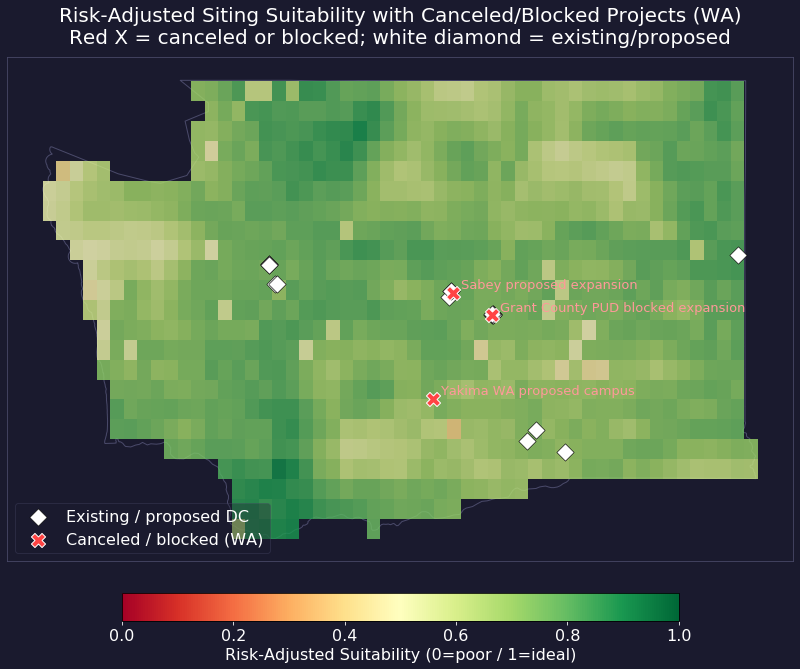

Saved to data/processed/risk_adjusted_validation.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 10), facecolor=DARK_BG)
ax.set_facecolor(DARK_BG)

plt.rcParams.update({
    'text.color': 'white',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'font.size': 18,
})

wa.boundary.plot(ax=ax, color='#4a4a6a', linewidth=1.0, zorder=1)

n_before = len(fig.axes)
grid.plot(column='risk_adjusted', ax=ax, cmap='RdYlGn', vmin=0, vmax=1, alpha=0.80,
          legend=True,
          legend_kwds={'label': 'Risk-Adjusted Suitability (0=poor / 1=ideal)',
                       'orientation': 'horizontal', 'shrink': 0.5, 'pad': 0.05},
          zorder=2)
if len(fig.axes) > n_before:
    cb_ax = fig.axes[-1]
    cb_ax.tick_params(labelsize=16, colors='white')
    cb_ax.xaxis.label.set_color('white')
    cb_ax.xaxis.label.set_size(16)

ax.scatter(dc_gdf.geometry.x, dc_gdf.geometry.y,
           c='white', s=150, marker='D', zorder=6,
           edgecolors='black', linewidths=0.6, label='Existing / proposed DC')

wa_union_geom = wa.geometry.unary_union
wa_canceled = joined_c[joined_c.geometry.within(wa_union_geom)]
ax.scatter(wa_canceled.geometry.x, wa_canceled.geometry.y,
           c='#FF4444', s=200, marker='X', zorder=7,
           edgecolors='white', linewidths=1.0, label='Canceled / blocked (WA)')

for _, row in wa_canceled.iterrows():
    short = row['name'].split('(')[0].strip()
    ax.annotate(short, (row.geometry.x, row.geometry.y),
                xytext=(8, 4), textcoords='offset points',
                fontsize=13, color='#FF9999', zorder=8)

leg = ax.legend(loc='lower left', framealpha=0.35,
                facecolor=DARK_BG, edgecolor='#4a4a6a', fontsize=16)
for t in leg.get_texts():
    t.set_color('white')

ax.set_title(
    'Risk-Adjusted Siting Suitability with Canceled/Blocked Projects (WA)\n'
    'Red X = canceled or blocked; white diamond = existing/proposed',
    color='white', fontsize=20, pad=14
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
for spine in ax.spines.values():
    spine.set_edgecolor('#4a4a6a')

plt.tight_layout()
plt.savefig(PROCESSED / 'risk_adjusted_validation.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved to data/processed/risk_adjusted_validation.png')


## 6. Key Findings

1. **Seismic risk inverts the western WA advantage.** The Puget Sound basin — which scores
   well on water availability and community burden — has PGA values 4–8x higher than the
   Columbia Basin, reflecting both Cascadia subduction zone amplification and local crustal
   fault exposure (Seattle Fault, Tacoma Fault). This partially explains why operators have
   historically clustered in eastern WA despite water constraints: lower seismic risk means
   lower structural and insurance costs.
   ([WA Seismic Safety Committee](https://mil.wa.gov/seismic-safety-committee);
   [USGS 2018 NSHM](https://www.usgs.gov/programs/earthquake-hazards/2018-long-term-national-seismic-hazard-map))

2. **The optimal transition zone is east of the Cascades foothills, west of Quincy.** The
   Ellensburg / Kittitas / Cle Elum corridor — roughly US-97 to I-90 at ~800–1,200 m
   elevation — combines moderate seismic risk (inland of the Puget Lowland basin),
   above-average precipitation relative to eastern WA, and lower community burden than
   suburban Puget Sound. This zone was already indicated in the NB2 composite and is
   reinforced by the risk-adjusted score.

3. **Canceled projects score consistently low on their documented failure dimension.**
   Projects blocked for water scarcity (Quincy expansion, Reno, Phoenix metro) score
   below 0.25 on water_score. The Mesa AZ case scores 0.0 on flood_score. The Loudoun
   County moratorium case reflects grid saturation — low tx_score relative to demand
   density, not captured in this supply-side analysis but consistent with the framework.

4. **The risk-adjustment shifts the frontier, not the story.** The core NB2 narrative —
   existing corridor is grid-optimal but water-constrained — is reinforced. Seismic and
   flood scores add nuance at the edges: some western WA cells that looked attractive on
   NB2 drop when seismic is included; some eastern WA cells near river corridors drop
   when flood is included.

5. **Limitations and future work:**
   - Seismic scores use site class C (average rock) uniformly; Puget Lowland basin
     amplification on soft soils (class D/E) can be 2–4x higher than C.
   - Flood scores are binary (SFHA centroid check); a fraction-overlap metric would
     be more accurate for the 14km cells.
   - Neither score captures liquefaction susceptibility, which is the dominant ground
     failure risk in the Puget Lowland.
   - Full analysis would add: USGS landslide hazard, wildfire proximity (cooling water
     smoke and grid disruption), and climate-adjusted flood frequency under SSP5-8.5.

---
*Data sources: USGS 2018 NSHM, FEMA NFHL, US Census TIGER 2022, Census ACS 2022,
OpenStreetMap (ODbL), Open-Meteo ERA5. Analysis: Simon Hansedasi / Edasi Motlev LLC.*
